In [12]:
# Check if there's a torch folder in your current directory
!ls -la | grep torch

# If you see a 'torch' folder or 'torch.py' file, remove it
!rm -rf torch
!rm -f torch.py

In [14]:
# 1. Exit Python/Jupyter completely
# Close all notebooks and terminals

# 2. Uninstall PyTorch
!pip uninstall torch torchvision torchaudio -y

# 3. Clear all caches
!pip cache purge
!rm -rf ~/.cache/torch
!rm -rf ~/.cache/pip

# 4. Install fresh PyTorch (CPU version - most stable)
!pip install --no-cache-dir torch==2.0.1 torchvision==0.15.2 --extra-index-url https://download.pytorch.org/whl/cpu

Found existing installation: torch 2.0.1+cu118
Uninstalling torch-2.0.1+cu118:
  Successfully uninstalled torch-2.0.1+cu118
Found existing installation: torchvision 0.15.2+cu118
Uninstalling torchvision-0.15.2+cu118:
  Successfully uninstalled torchvision-0.15.2+cu118
ERROR: unknown command "cache" - maybe you meant "check"
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
     |████████████████████████████████| 195.4 MB 47.9 MB/s eta 0:00:01
     |████████████████████████████████| 24.9 MB 137.3 MB/s eta 0:00:01     |██████████████████████████████▎ | 23.6 MB 137.3 MB/s eta 0:00:01


VAE

In [1]:
# =======================
# VAE + Vector Arithmetic
# =======================
# Run in Colab / local Python. Keep device config and training params as needed.

import math, json, random, urllib.request, zipfile, tempfile, shutil
from pathlib import Path
from typing import List, Tuple
import sys, os

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from PIL import Image
from tqdm.auto import tqdm

# -----------------------
# CONFIG
# -----------------------
IMG_SIZE      = 256
LATENT_DIM    = 256
BASE_CH       = 64
EPOCHS        = 10
BATCH         = 32
LR            = 1e-3
VAL_SPLIT     = 0.05
BETA          = 1.0
SEED          = 42
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
ROOT = Path("./vae_morph_data")
ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = ROOT / "vae_latest.pt"
BEST_PATH = ROOT / "vae_best.pt"
FINAL_MODEL_PATH = ROOT / "vae_final.pt"
torch.manual_seed(SEED); random.seed(SEED)

# COCO (optional) — change or skip if you use another dataset
COCO_VAL_URL = "http://images.cocodataset.org/zips/val2017.zip"
COCO_ANN_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

# -----------------------
# UTIL: download / extract (optional)
# -----------------------
def download_file(url: str, dest: Path):
    if dest.exists():
        return
    dest.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(delete=False) as tmp:
        urllib.request.urlretrieve(url, tmp.name)
        shutil.move(tmp.name, dest)

def download_coco(root: Path, n: int = 5000) -> List[Tuple[str, str]]:
    data_root = root / "data"
    val_zip = data_root / "val2017.zip"
    ann_zip = data_root / "annotations_trainval2017.zip"
    meta_path = data_root / "metadata.json"
    download_file(COCO_VAL_URL, val_zip)
    download_file(COCO_ANN_URL, ann_zip)
    if meta_path.exists():
        try:
            return json.load(open(meta_path))
        except Exception:
            pass
    try:
        with zipfile.ZipFile(val_zip, 'r') as zf:
            if not (data_root / "val2017").exists():
                zf.extractall(data_root)
        with zipfile.ZipFile(ann_zip, 'r') as zf:
            if not (data_root / "annotations").exists():
                zf.extractall(data_root)
        captions_path = data_root / "annotations" / "captions_val2017.json"
        with open(captions_path, 'r') as f:
            captions = json.load(f)
        id_to_filename = {img['id']: img['file_name'] for img in captions['images']}
        metadata = []
        used_ids = set()
        for ann in captions['annotations']:
            img_id = ann['image_id']
            if img_id in id_to_filename and img_id not in used_ids:
                metadata.append((id_to_filename[img_id], ann['caption']))
                used_ids.add(img_id)
                if len(metadata) >= n:
                    break
        with open(meta_path, 'w') as f:
            json.dump(metadata, f)
        return metadata
    except Exception:
        return []

# -----------------------
# MODEL
# -----------------------
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, c), nn.SiLU(), nn.Conv2d(c, c, 3, padding=1),
            nn.GroupNorm(8, c), nn.SiLU(), nn.Conv2d(c, c, 3, padding=1)
        )
    def forward(self, x):
        return x + self.block(x)

class TinyVAE(nn.Module):
    def __init__(self, latent=LATENT_DIM, base=BASE_CH):
        super().__init__()
        self.latent = latent
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, base, 4, 2, 1), nn.SiLU(), ResBlock(base), # 128
            nn.Conv2d(base, base*2, 4, 2, 1), nn.SiLU(), ResBlock(base*2), #64
            nn.Conv2d(base*2, base*4, 4, 2, 1), nn.SiLU(), ResBlock(base*4), #32
            nn.Conv2d(base*4, base*8, 4, 2, 1), nn.SiLU(), ResBlock(base*8), #16
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(base*8, latent*2, 1)  # mean & logvar as channels
        )
        # Decoder
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(latent, base*8, 16, 1, 0), nn.SiLU(), ResBlock(base*8), # 1->16
            nn.ConvTranspose2d(base*8, base*4, 4, 2, 1), nn.SiLU(), ResBlock(base*4), #16->32
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1), nn.SiLU(), ResBlock(base*2), #32->64
            nn.ConvTranspose2d(base*2, base, 4, 2, 1), nn.SiLU(), ResBlock(base), #64->128
            nn.ConvTranspose2d(base, 3, 4, 2, 1)
        )

    def encode(self, x):
        h = self.enc(x)                 # [B, latent*2, 1, 1]
        mean, logvar = h.chunk(2, dim=1)
        return mean, logvar              # shapes: [B, latent, 1, 1]

    def reparam(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def decode(self, z):
        # z expected [B, latent] or [B, latent, 1, 1]
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        out = self.dec(z)
        return torch.tanh(out)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparam(mean, logvar)
        recon = self.decode(z)
        # KL per-sample
        kl = 0.5 * torch.sum(torch.exp(logvar) + mean**2 - 1 - logvar, dim=[1,2,3])
        return recon, mean, logvar, kl

# -----------------------
# LOSS (consistent & debuggable)
# -----------------------
def vae_loss(recon_x: torch.Tensor, x: torch.Tensor, kl_per_sample: torch.Tensor, beta: float = BETA):
    # recon: pixelwise MSE mean over batch
    # Keep both per-sample-sum and per-pixel-mean for logging.
    per_sample_mse = F.mse_loss(recon_x, x, reduction='none').view(recon_x.size(0), -1).mean(dim=1)  # per-sample mean pixel MSE
    reconstruction_loss = per_sample_mse.mean()  # scalar
    kl = kl_per_sample.mean()                    # scalar
    total = reconstruction_loss + beta * kl
    return total, reconstruction_loss, kl

# -----------------------
# DATASET
# -----------------------
class VAEDataset(Dataset):
    def __init__(self, meta_list: List[Tuple[str, str]], root: Path, size=IMG_SIZE):
        self.root = root / "data" / "val2017"
        self.size = size
        self.meta = list(meta_list)
        self.transform = transforms.Compose([
            transforms.Resize(size),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])
    def __len__(self): return len(self.meta)
    def __getitem__(self, idx):
        fname, cap = self.meta[idx]
        img_path = self.root / fname
        try:
            img = Image.open(img_path).convert("RGB")
            img_tensor = self.transform(img)
        except Exception:
            img_tensor = torch.zeros(3, self.size, self.size)
        return img_tensor, cap

def collate(batch):
    imgs, caps = zip(*batch)
    return torch.stack(imgs, dim=0), list(caps)

# -----------------------
# TRAIN / VAL split FIXED
# -----------------------
def train_vae(data_root=ROOT, epochs=EPOCHS, batch=BATCH, resume=True, use_coco=True):
    # 1) Load metadata
    if use_coco:
        meta_list = download_coco(data_root)
    else:
        # If user supplies a list or folder, they'd set meta_list accordingly.
        raise RuntimeError("Set use_coco=True or provide meta_list manually.")
    if not meta_list:
        print("No metadata found. Aborting.")
        return TinyVAE(LATENT_DIM, BASE_CH).to(DEVICE).eval()

    # deterministic split (shuffled by seed)
    rng = torch.Generator().manual_seed(SEED)
    n = len(meta_list)
    indices = list(range(n))
    random.Random(SEED).shuffle(indices)
    train_len = int(n * (1 - VAL_SPLIT))
    train_idx = indices[:train_len]
    val_idx = indices[train_len:]
    train_meta = [meta_list[i] for i in train_idx]
    val_meta = [meta_list[i] for i in val_idx]

    train_dataset = VAEDataset(train_meta, data_root)
    val_dataset = VAEDataset(val_meta, data_root)

    train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True, num_workers=2, collate_fn=collate)
    val_loader = DataLoader(val_dataset, batch_size=batch, shuffle=False, num_workers=2, collate_fn=collate)

    # 2) Model, optimizer, scheduler
    vae = TinyVAE(LATENT_DIM, BASE_CH).to(DEVICE)
    optimizer = torch.optim.Adam(vae.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    start_epoch = 0
    best_val_loss = float('inf')

    # Handle different saved formats gracefully
    def load_model_if_exists(path):
        if not path.exists(): return None
        data = torch.load(path, map_location=DEVICE)
        # support either state_dict only or {"model":..., "opt":..., ...}
        if isinstance(data, dict) and "model" in data:
            vae.load_state_dict(data["model"])
            if "opt" in data:
                optimizer.load_state_dict(data["opt"])
            if "scheduler" in data:
                try:
                    scheduler.load_state_dict(data["scheduler"])
                except Exception:
                    pass
            return data
        else:
            try:
                vae.load_state_dict(data)
                return {"model": data}
            except Exception:
                return None

    # Optionally resume
    if resume and CHECKPOINT_PATH.exists():
        ckpt = load_model_if_exists(CHECKPOINT_PATH)
        if ckpt and "epoch" in ckpt:
            start_epoch = ckpt["epoch"] + 1
            best_val_loss = ckpt.get("loss", best_val_loss)

    # If a final model exists, return it (eval)
    if FINAL_MODEL_PATH.exists():
        loaded = load_model_if_exists(FINAL_MODEL_PATH)
        return vae.eval()

    # Training loop
    for epoch in range(start_epoch, epochs):
        vae.train()
        total_train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}/{epochs}", leave=False)
        for imgs, _ in pbar:
            imgs = imgs.to(DEVICE)
            optimizer.zero_grad()
            recon, mean, logvar, kl = vae(imgs)
            loss, recon_l, kl_l = vae_loss(recon, imgs, kl)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "recon": f"{recon_l.item():.4f}", "kl": f"{kl_l.item():.4f}"})
        avg_train = total_train_loss / len(train_loader)
        scheduler.step()

        # Validation
        vae.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in tqdm(val_loader, desc=f"Val Epoch {epoch}/{epochs}", leave=False):
                imgs = imgs.to(DEVICE)
                recon, mean, logvar, kl = vae(imgs)
                loss, _, _ = vae_loss(recon, imgs, kl)
                total_val_loss += loss.item()
        avg_val = total_val_loss / len(val_loader)

        # Save checkpoint (consistent format)
        ckpt_state = {
            "epoch": epoch,
            "model": vae.state_dict(),
            "opt": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "loss": avg_val
        }
        torch.save(ckpt_state, CHECKPOINT_PATH)
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(ckpt_state, BEST_PATH)

        print(f"Epoch {epoch} finished. Train: {avg_train:.4f}, Val: {avg_val:.4f}")

    # final save
    final_state = {"epoch": epochs-1, "model": vae.state_dict(), "opt": optimizer.state_dict(), "scheduler": scheduler.state_dict(), "loss": best_val_loss}
    torch.save(final_state, FINAL_MODEL_PATH)
    return vae.eval()

# -----------------------
# INFERENCE / BLENDING HELPERS (DETERMINISTIC MEAN)
# -----------------------
@torch.no_grad()
def encode_mean(vae: TinyVAE, img_tensor: torch.Tensor):
    vae.eval()
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    img_tensor = img_tensor.to(DEVICE)
    mean, _ = vae.encode(img_tensor)           # [B, latent, 1, 1]
    mean = mean.view(mean.size(0), -1)         # [B, latent]
    return mean

@torch.no_grad()
def decode_from_latent(vae: TinyVAE, z: torch.Tensor):
    vae.eval()
    if z.dim() == 1:
        z = z.unsqueeze(0)
    z = z.to(DEVICE)
    return vae.decode(z)                       # returns [-1,1] image tensor

def slerp(a: torch.Tensor, b: torch.Tensor, t: float):
    a_n = F.normalize(a, dim=1)
    b_n = F.normalize(b, dim=1)
    dot = (a_n * b_n).sum(dim=1).clamp(-1+1e-7, 1-1e-7)
    omega = torch.acos(dot)
    so = torch.sin(omega)
    t = torch.tensor(t, device=a.device)
    # handle small angle -> linear
    small = (so.abs() < 1e-3)
    out = torch.zeros_like(a)
    for i in range(a.size(0)):
        if small[i]:
            out[i] = (1 - t) * a[i] + t * b[i]
        else:
            out[i] = (torch.sin((1 - t) * omega[i]) / so[i]) * a[i] + (torch.sin(t * omega[i]) / so[i]) * b[i]
    return out

@torch.no_grad()
def blend(vae: TinyVAE, imgA: torch.Tensor, imgB: torch.Tensor, alpha: float = 0.5, use_slerp: bool = False, subtract_mean: bool = True, dataset_mean: torch.Tensor = None):
    za = encode_mean(vae, imgA)  # [1, latent]
    zb = encode_mean(vae, imgB)
    if subtract_mean:
        if dataset_mean is None:
            dataset_mean = torch.zeros_like(za)
        za = za - dataset_mean
        zb = zb - dataset_mean
    if use_slerp:
        z = slerp(za, zb, alpha)
    else:
        z = alpha * za + (1 - alpha) * zb
    if subtract_mean:
        z = z + dataset_mean
    return decode_from_latent(vae, z)

# -----------------------
# CLASS AVERAGING helper (compute average latent for a set of image tensors)
# -----------------------
@torch.no_grad()
def compute_concept_latent_mean(vae: TinyVAE, image_tensors: List[torch.Tensor], batch_size: int = 16):
    vae.eval()
    acc = []
    for i in range(0, len(image_tensors), batch_size):
        batch = torch.stack(image_tensors[i:i+batch_size]).to(DEVICE)
        mean, _ = vae.encode(batch)
        mean = mean.view(mean.size(0), -1)
        acc.append(mean.cpu())
    acc_t = torch.cat(acc, dim=0)
    return acc_t.mean(dim=0, keepdim=True)  # [1, latent]

# -----------------------
# SIMPLE USAGE EXAMPLE (not executed automatically)
# -----------------------
if __name__ == "__main__":
    # 1) Train (or load)
    vae = train_vae(epochs=EPOCHS, batch=BATCH, resume=True, use_coco=True)

    # 2) Load two sample images from data folder (adjust filenames)
    data_root = ROOT / "data" / "val2017"
    # example file names (ensure these are present, replace with actual)
    sample_a = data_root / "000000000139.jpg"  # replace with real file
    sample_b = data_root / "000000000285.jpg"  # replace with real file

    preprocess = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    def load_img(p):
        try:
            im = Image.open(p).convert("RGB")
            return preprocess(im)
        except Exception:
            return torch.zeros(3, IMG_SIZE, IMG_SIZE)

    a = load_img(sample_a)
    b = load_img(sample_b)

    # 3) Compute class means (optional)
    # If you have many images for "crocodile" and "brass instrument", compute each concept mean:
    # mean_croc = compute_concept_latent_mean(vae, crocodile_image_tensors)
    # mean_instr = compute_concept_latent_mean(vae, instrument_image_tensors)

    # 4) Simple blend: deterministic means + linear interpolation
    out = blend(vae, a, b, alpha=0.6, use_slerp=False)
    # out is a tensor in [-1,1]. Convert to displayable image if desired:
    from torchvision.transforms.functional import to_pil_image
    img = (out[0].cpu().add(1).div(2).clamp(0,1))  # -> [0,1]
    pil = to_pil_image(img)
    pil.save(ROOT / "blend_example.png")
    print("Saved blend_example.png")

/home/gedo/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1 finished. Train: 0.3364, Val: 0.3215


Epoch 2 finished. Train: 0.3166, Val: 0.3067


Epoch 3 finished. Train: 0.3086, Val: 0.3043


Epoch 4 finished. Train: 0.3048, Val: 0.3024


Epoch 5 finished. Train: 0.3025, Val: 0.2977


Epoch 6 finished. Train: 0.3007, Val: 0.2965


Epoch 7 finished. Train: 0.2997, Val: 0.2954


Epoch 8 finished. Train: 0.2992, Val: 0.2951


Epoch 9 finished. Train: 0.2988, Val: 0.2947
Saved blend_example.png


CHECKPOINT INSPECTION & MODEL TESTING UTILITY


CURRENT CONFIGURATION
   Image Size          : 256
   Latent Dimension    : 256
   Base Channels       : 64
   Epochs              : 10
   Batch Size          : 32
   Learning Rate       : 0.001
   Validation Split    : 0.05
   Beta (KL weight)    : 1.0
   Device              : cpu
   Random Seed         : 42
FILE STRUCTURE CHECK

 Root directory: vae_morph_data
   Exists: True

 Data directory: vae_morph_data/data/val2017
   Exists: True
   Images found: 5000
   Sample images: ['000000136033.jpg', '000000225184.jpg', '000000104666.jpg']

 Metadata file: vae_morph_data/data/metadata.json
   Exists: True
   Entries: 5000

 Model checkpoints:
   Latest checkpoint: vae_morph_data/vae_latest.pt
      Exists: True
      Size: 593.76 MB
   Best checkpoint: vae_morph_data/vae_best.pt
      Exists: True
      Size: 593.76 MB
   Final model: vae_morph_data/vae_final.pt
      Exists: True
      Size: 593.76 MB

CHECKPOINT COMPARISON

Checkpoint   Epoch      Val Loss        Size (MB) 
----------

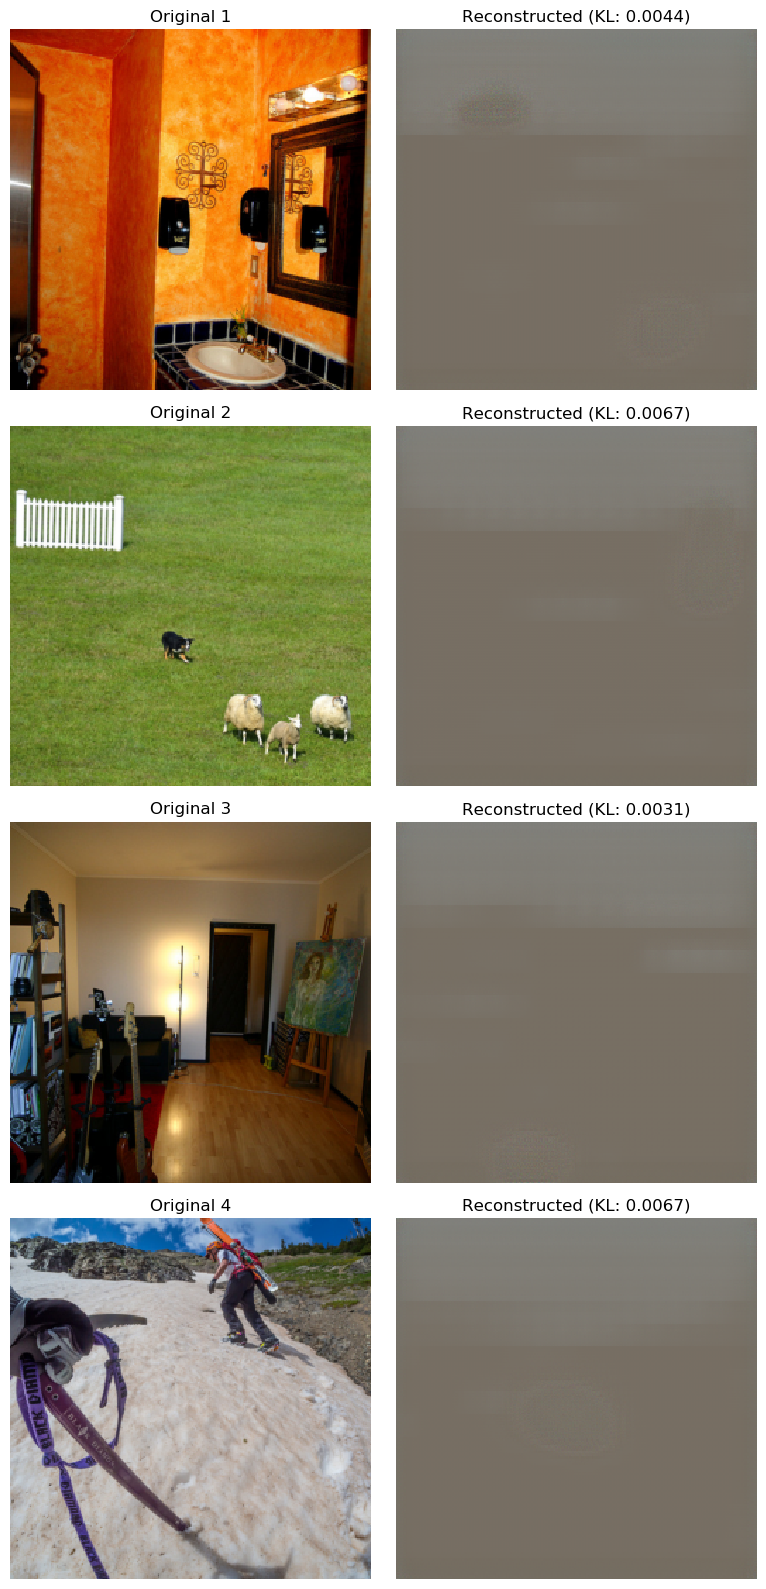


 ALL CHECKS COMPLETED!

Next steps:
  1. If KL divergence is too low (<0.01), retrain with lower beta
  2. If reconstructions look good, proceed with blending tests
  3. To resume training: train_vae(epochs=20, resume=True)


In [ ]:
import torch
from pathlib import Path
import json
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image

# -----------------------
# 1. CHECK FILE STRUCTURE
# -----------------------
def check_file_structure():
    """Check if all required files and folders exist"""
    print("="*60)
    print("FILE STRUCTURE CHECK")
    print("="*60)
    
    # Check root directory
    print(f"\n Root directory: {ROOT}")
    print(f"   Exists: {ROOT.exists()}")
    
    # Check data directory
    data_root = ROOT / "data" / "val2017"
    print(f"\n Data directory: {data_root}")
    print(f"   Exists: {data_root.exists()}")
    if data_root.exists():
        image_files = list(data_root.glob("*.jpg"))
        print(f"   Images found: {len(image_files)}")
        if len(image_files) > 0:
            print(f"   Sample images: {[f.name for f in image_files[:3]]}")
    
    # Check metadata
    meta_path = ROOT / "data" / "metadata.json"
    print(f"\n Metadata file: {meta_path}")
    print(f"   Exists: {meta_path.exists()}")
    if meta_path.exists():
        try:
            with open(meta_path, 'r') as f:
                metadata = json.load(f)
            print(f"   Entries: {len(metadata)}")
        except Exception as e:
            print(f"   Error reading: {e}")
    
    # Check model checkpoints
    print(f"\n Model checkpoints:")
    for name, path in [
        ("Latest checkpoint", CHECKPOINT_PATH),
        ("Best checkpoint", BEST_PATH),
        ("Final model", FINAL_MODEL_PATH)
    ]:
        print(f"   {name}: {path}")
        print(f"      Exists: {path.exists()}")
        if path.exists():
            size_mb = path.stat().st_size / (1024 * 1024)
            print(f"      Size: {size_mb:.2f} MB")

# -----------------------
# 2. INSPECT CHECKPOINT DETAILS
# -----------------------
def inspect_checkpoint(checkpoint_path):
    """Detailed inspection of a checkpoint file"""
    print("\n" + "="*60)
    print(f"CHECKPOINT INSPECTION: {checkpoint_path.name}")
    print("="*60)
    
    if not checkpoint_path.exists():
        print(f" Checkpoint not found!")
        return None
    
    try:
        ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        
        print(f"\n Checkpoint loaded successfully")
        print(f"\n Checkpoint contents:")
        
        if isinstance(ckpt, dict):
            print(f"   Type: Dictionary")
            print(f"   Keys: {list(ckpt.keys())}")
            
            # Check epoch
            if "epoch" in ckpt:
                print(f"\n    Training info:")
                print(f"      Epoch: {ckpt['epoch']}")
                print(f"      Validation loss: {ckpt.get('loss', 'N/A'):.6f}" if 'loss' in ckpt else "      Loss: Not available")
            
            # Check model state dict
            if "model" in ckpt:
                model_dict = ckpt["model"]
                print(f"\n    Model state dict:")
                print(f"      Number of parameters: {len(model_dict)}")
                print(f"      Sample keys: {list(model_dict.keys())[:5]}")
                
                # Calculate total parameters
                total_params = sum(p.numel() for p in model_dict.values())
                print(f"      Total parameters: {total_params:,}")
                print(f"      Model size: {total_params * 4 / (1024**2):.2f} MB (float32)")
            
            # Check optimizer
            if "opt" in ckpt:
                print(f"\n     Optimizer state: Present")
            
            # Check scheduler
            if "scheduler" in ckpt:
                print(f"    Scheduler state: Present")
        
        else:
            print(f"   Type: State dict (legacy format)")
            print(f"   Parameters: {len(ckpt)}")
        
        return ckpt
        
    except Exception as e:
        print(f" Error loading checkpoint: {e}")
        return None

# -----------------------
# 3. COMPARE CHECKPOINTS
# -----------------------
def compare_checkpoints():
    """Compare all available checkpoints"""
    print("\n" + "="*60)
    print("CHECKPOINT COMPARISON")
    print("="*60)
    
    checkpoints = [
        ("Latest", CHECKPOINT_PATH),
        ("Best", BEST_PATH),
        ("Final", FINAL_MODEL_PATH)
    ]
    
    results = []
    for name, path in checkpoints:
        if path.exists():
            try:
                ckpt = torch.load(path, map_location='cpu', weights_only=False)
                if isinstance(ckpt, dict):
                    results.append({
                        'name': name,
                        'epoch': ckpt.get('epoch', 'N/A'),
                        'loss': ckpt.get('loss', 'N/A'),
                        'size_mb': path.stat().st_size / (1024 * 1024)
                    })
            except Exception as e:
                print(f"Error loading {name}: {e}")
    
    if results:
        print(f"\n{'Checkpoint':<12} {'Epoch':<10} {'Val Loss':<15} {'Size (MB)':<10}")
        print("-" * 60)
        for r in results:
            epoch = r['epoch'] if r['epoch'] != 'N/A' else 'N/A'
            loss = f"{r['loss']:.6f}" if r['loss'] != 'N/A' else 'N/A'
            print(f"{r['name']:<12} {str(epoch):<10} {loss:<15} {r['size_mb']:.2f}")
    else:
        print("No checkpoints found!")

# -----------------------
# 4. LOAD AND TEST MODEL
# -----------------------
@torch.no_grad()
def load_and_test_model(checkpoint_path=BEST_PATH):
    """Load model and perform basic tests"""
    print("\n" + "="*60)
    print("MODEL LOADING & TESTING")
    print("="*60)
    
    # Load model
    print(f"\n Loading model from: {checkpoint_path}")
    try:
        vae = TinyVAE(LATENT_DIM, BASE_CH).to(DEVICE)
        ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        
        if isinstance(ckpt, dict) and "model" in ckpt:
            vae.load_state_dict(ckpt["model"])
            print(f" Model loaded from epoch {ckpt.get('epoch', 'unknown')}")
            print(f"   Validation loss: {ckpt.get('loss', 'N/A'):.6f}" if 'loss' in ckpt else "")
        else:
            vae.load_state_dict(ckpt)
            print(f" Model loaded (legacy format)")
        
        vae.eval()
        
        # Test forward pass
        print(f"\n Testing forward pass...")
        dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
        recon, mean, logvar, kl = vae(dummy_input)
        
        print(f"   Input shape: {dummy_input.shape}")
        print(f"   Output shape: {recon.shape}")
        print(f"   Latent mean shape: {mean.shape}")
        print(f"   Output range: [{recon.min():.3f}, {recon.max():.3f}]")
        print(f"   KL divergence: {kl.mean():.6f}")
        
        # Check if model has collapsed
        if kl.mean() < 0.01:
            print(f"     WARNING: Very low KL divergence - model may have collapsed!")
        elif kl.mean() > 100:
            print(f"     WARNING: Very high KL divergence - model may not be trained!")
        else:
            print(f"    KL divergence looks reasonable")
        
        return vae
        
    except Exception as e:
        print(f" Error loading model: {e}")
        return None

# -----------------------
# 5. TEST RECONSTRUCTION
# -----------------------
@torch.no_grad()
def test_reconstruction_quality(vae, num_samples=4):
    """Test reconstruction on real images"""
    print("\n" + "="*60)
    print("RECONSTRUCTION QUALITY TEST")
    print("="*60)
    
    data_root = ROOT / "data" / "val2017"
    image_files = list(data_root.glob("*.jpg"))[:num_samples]
    
    if len(image_files) == 0:
        print(" No images found for testing!")
        return
    
    print(f"\n Testing on {len(image_files)} images")
    
    transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_path in enumerate(image_files):
        try:
            # Load and preprocess
            img = Image.open(img_path).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(DEVICE)
            
            # Reconstruct
            recon, mean, logvar, kl = vae(img_tensor)
            
            # Convert to displayable format
            def to_display(tensor):
                t = tensor[0].cpu().clone()
                t = (t + 1) / 2  # [-1,1] -> [0,1]
                t = t.clamp(0, 1)
                return t.permute(1, 2, 0).numpy()
            
            # Display
            axes[idx, 0].imshow(to_display(img_tensor))
            axes[idx, 0].set_title(f"Original {idx+1}")
            axes[idx, 0].axis('off')
            
            axes[idx, 1].imshow(to_display(recon))
            axes[idx, 1].set_title(f"Reconstructed (KL: {kl.mean():.4f})")
            axes[idx, 1].axis('off')
            
            print(f"   Image {idx+1}: KL={kl.mean():.4f}, Range=[{recon.min():.3f}, {recon.max():.3f}]")
            
        except Exception as e:
            print(f"   Error with image {idx+1}: {e}")
    
    plt.tight_layout()
    
    # Save result
    result_path = ROOT / "reconstruction_test.png"
    plt.savefig(result_path, dpi=150, bbox_inches='tight')
    print(f"\n Saved reconstruction test to: {result_path}")
    plt.show()

# -----------------------
# 6. CHECK CONFIGURATION
# -----------------------
def check_configuration():
    """Display current configuration"""
    print("\n" + "="*60)
    print("CURRENT CONFIGURATION")
    print("="*60)
    
    config = {
        "Image Size": IMG_SIZE,
        "Latent Dimension": LATENT_DIM,
        "Base Channels": BASE_CH,
        "Epochs": EPOCHS,
        "Batch Size": BATCH,
        "Learning Rate": LR,
        "Validation Split": VAL_SPLIT,
        "Beta (KL weight)": BETA,
        "Device": DEVICE,
        "Random Seed": SEED
    }
    
    for key, value in config.items():
        print(f"   {key:<20}: {value}")
    
    # Check device details
    if DEVICE == "cuda" and torch.cuda.is_available():
        print(f"\n  GPU Information:")
        print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"   Total Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"   CUDA Version: {torch.version.cuda}")

# -----------------------
# 7. RUN ALL CHECKS
# -----------------------
def run_all_checks():
    """Run all diagnostic checks"""
    check_configuration()
    check_file_structure()
    compare_checkpoints()
    
    # Inspect each checkpoint
    for name, path in [("Best", BEST_PATH), ("Latest", CHECKPOINT_PATH), ("Final", FINAL_MODEL_PATH)]:
        if path.exists():
            inspect_checkpoint(path)
    
    # Load and test model
    vae = load_and_test_model(BEST_PATH)
    
    if vae is not None:
        test_reconstruction_quality(vae, num_samples=4)
        
        print("\n" + "="*60)
        print(" ALL CHECKS COMPLETED!")
        print("="*60)
        print("\nNext steps:")
        print("  1. If KL divergence is too low (<0.01), retrain with lower beta")
        print("  2. If reconstructions look good, proceed with blending tests")
        print("  3. To resume training: train_vae(epochs=20, resume=True)")
    
    return vae

# -----------------------
# 8. EXECUTE
# -----------------------
if __name__ == "__main__":
    vae = run_all_checks()